# 🛫 Prévision des Retards Aériens — Notebook MLflow
**Projet PPML — 5 plus grands aéroports français**

Workflow :
1. Configuration & Imports
2. Connexion MLflow
3. Chargement des données (S3)
4. Analyse Exploratoire (EDA)
5. Nettoyage des données
6. Feature Engineering
7. Préparation pour la modélisation
8. Modélisation & Logging MLflow
9. Optimisation du meilleur modèle
10. Analyse des importances de variables

## 1. Configuration & Imports

In [2]:
# =====================================================================
# IMPORTS GLOBAUX
# Toutes les dépendances centralisées ici
# éparpillés dans le notebook
# =====================================================================

import os
import warnings
import numpy as np
import pandas as pd
import boto3
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.base import clone

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

from dotenv import load_dotenv

# Chargement des variables d'environnement (.env)
load_dotenv(override=True)

# Options d'affichage Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
warnings.filterwarnings('ignore')

print("✅ Imports OK")

✅ Imports OK


## 2. Connexion MLflow

In [3]:
# =====================================================================
# CONFIGURATION MLFLOW
# Serveur distant hébergé sur Hugging Face Spaces
# =====================================================================

#MLFLOW_REMOTE_URI = "https://patjedhahf-mlflow-ppml.hf.space/"
MLFLOW_REMOTE_URI = "https://stoneray-ppml-mlflow.hf.space/"
EXPERIMENT_NAME   = "ppml-retards-avion"

mlflow.set_tracking_uri(MLFLOW_REMOTE_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ MLflow connecté  : {MLFLOW_REMOTE_URI}")
print(f"   Expérience     : {EXPERIMENT_NAME}")

✅ MLflow connecté  : https://stoneray-ppml-mlflow.hf.space/
   Expérience     : ppml-retards-avion


## 3. Chargement des données

**Source :** AWS S3 (format Parquet)

**Datasets :**
- `df_train` → données historiques pour l'entraînement
- `df_predict` → données d'avril 2026 pour la prédiction finale

In [4]:
# =====================================================================
# FONCTION DE CHARGEMENT S3
# Centralise la session boto3 et la lecture Parquet pour éviter
# la duplication du code de connexion dans chaque cellule
# =====================================================================

def get_s3_parquet(s3_key: str) -> pd.DataFrame:
    """Charge un fichier Parquet depuis le bucket S3 de l'équipe."""
    session = boto3.Session(
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID_EQUIPE"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY_EQUIPE"),
        region_name="eu-north-1",
    )
    bucket = os.getenv("BUCKET_EQUIPE")
    return pd.read_parquet(f"s3://{bucket}/{s3_key}")


# --- Chemins S3 ---
S3_TRAIN   = "prod/train/full_training_2025-10-05_to_2026-04-06.parquet"
S3_PREDICT = "prod/predict/prediction_avril2026.parquet"

# --- Chargement ---
print("Chargement des données d'entraînement...")
df_train = get_s3_parquet(S3_TRAIN)
print(f"  df_train   : {df_train.shape[0]:,} lignes | {df_train.shape[1]} colonnes")

print("Chargement des données de prédiction...")
df_predict = get_s3_parquet(S3_PREDICT)
print(f"  df_predict : {df_predict.shape[0]:,} lignes | {df_predict.shape[1]} colonnes")

Chargement des données d'entraînement...
  df_train   : 264,759 lignes | 48 colonnes
Chargement des données de prédiction...
  df_predict : 35,604 lignes | 48 colonnes


In [5]:
# Aperçu rapide des colonnes disponibles
print("Colonnes df_train :")
print(df_train.columns.tolist())
df_train.head()

Colonnes df_train :
['date', 'icao', 'type', 'flight_number', 'call_sign', 'status', 'codeshare_status', 'is_cargo', 'scheduled_utc', 'revised_utc', 'runway_utc', 'delay_minutes', 'terminal_dep', 'terminal_arr', 'gate_dep', 'baggage_belt', 'destination_icao', 'destination_iata', 'destination_name', 'airline_name', 'airline_iata', 'airline_icao', 'aircraft_model', 'aircraft_reg', 'aircraft_mode_s', 'quality_dep', 'quality_arr', 'aircraft_family', 'num_seats', 'is_widebody', 'is_narrowbody', 'is_regional', 'aircraft_size_category', 'is_freighter', 'is_holiday', 'vac_school', 'is_holiday_eve', 'is_holiday_next', 'is_weekend', 'is_weekend_or_holiday', 'holiday_name', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_gusts_10m', 'pressure_msl', 'precipitation', 'cloud_cover']


,date,icao,type,flight_number,call_sign,status,codeshare_status,is_cargo,scheduled_utc,revised_utc,runway_utc,delay_minutes,terminal_dep,terminal_arr,gate_dep,baggage_belt,destination_icao,destination_iata,destination_name,airline_name,airline_iata,airline_icao,aircraft_model,aircraft_reg,aircraft_mode_s,quality_dep,quality_arr,aircraft_family,num_seats,is_widebody,is_narrowbody,is_regional,aircraft_size_category,is_freighter,is_holiday,vac_school,is_holiday_eve,is_holiday_next,is_weekend,is_weekend_or_holiday,holiday_name,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,pressure_msl,precipitation,cloud_cover
0,2025-10-05,LFPG,departure,BJ 521,LBT521,Departed,IsOperator,False,2025-10-04 20:05:00,2025-10-04 23:28Z,2025-10-04 23:28Z,203.0,3,None,None,None,DTTA,TUN,Tunis,Nouvelair Tunisie,BJ,LBT,Airbus A320,TS-INM,02A1AC,"[Basic, Live]",[],Airbus A320 Family,165,False,True,False,Medium,False,0,0,0,0,1,1,None,10.6,75,19.6,41.4,1013.8,0.0,23
1,2025-10-05,LFPG,departure,BJ 543,LBT543,Departed,IsOperator,False,2025-10-04 20:15:00,2025-10-04 22:35Z,2025-10-04 22:35Z,140.0,3,None,None,02,DTMB,MIR,Monastir,Nouvelair Tunisie,BJ,LBT,Airbus A320,TS-INR,02A1B1,"[Basic, Live]","[Basic, Live]",Airbus A320 Family,165,False,True,False,Medium,False,0,0,0,0,1,1,None,10.6,75,19.6,41.4,1013.8,0.0,23
2,2025-10-05,LFPG,departure,AF 406,AFR406,Departed,IsOperator,False,2025-10-04 21:20:00,2025-10-04 22:14Z,2025-10-04 22:14Z,54.0,2E,2,None,None,SCEL,SCL,Santiago,Air France,AF,AFR,Airbus A350-900,F-HTYT,39CF13,"[Basic, Live]",[Basic],Airbus A350,325,True,False,False,Very Large,False,0,0,0,0,1,1,None,10.4,77,19.9,38.9,1014.2,0.0,15
3,2025-10-05,LFPG,departure,AF 454,AFR454,Departed,IsOperator,False,2025-10-04 21:30:00,2025-10-04 22:03Z,2025-10-04 22:03Z,33.0,2E,3,None,None,SBGR,GRU,São Paulo,Air France,AF,AFR,Boeing 777-300,F-GSQY,394A18,"[Basic, Live]","[Basic, Live]",Boeing 777,355,True,False,False,Very Large,False,0,0,0,0,1,1,None,10.4,77,19.9,38.9,1014.2,0.0,15
4,2025-10-05,LFPG,departure,AF 116,AFR116,Departed,IsOperator,False,2025-10-04 21:45:00,2025-10-04 22:04Z,2025-10-04 22:04Z,19.0,2E,1,None,13,ZSPD,PVG,Shanghai,Air France,AF,AFR,Boeing 777,F-GZNS,3965B2,"[Basic, Live]","[Basic, Live]",Boeing 777,355,True,False,False,Very Large,False,0,0,0,0,1,1,None,10.1,77,19.9,38.9,1014.4,0.0,20


## 4. Analyse Exploratoire (EDA)

### 4.1 Statistiques générales

In [6]:
# =====================================================================
# STATISTIQUES GLOBALES
# =====================================================================

# Dictionnaire ICAO -> Nom — utilisé dans tout le notebook
AEROPORTS_CIBLES = {
    'LFPG': 'Roissy-CDG',
    'LFPO': 'Orly',
    'LFML': 'Marseille',
    'LFMN': 'Nice',
    'LFLL': 'Lyon',
}

print(f"Nb total de vols     : {len(df_train):,}")
print(f"Nb aéroports ICAO    : {df_train['icao'].nunique()}")

print("\n--- Statistiques globales de delay_minutes ---")
print(df_train['delay_minutes'].agg(['min', 'mean', 'median', 'max', 'std']).round(2))

print("\n--- Taux de valeurs manquantes (%) [colonnes > 0%] ---")
na_pct = (df_train.isna().sum() / len(df_train) * 100).sort_values(ascending=False)
print(na_pct[na_pct > 0].head(15))

Nb total de vols     : 264,759
Nb aéroports ICAO    : 5

--- Statistiques globales de delay_minutes ---
min       -695.00
mean        15.81
median      12.00
max       1233.00
std         32.45
Name: delay_minutes, dtype: float64

--- Taux de valeurs manquantes (%) [colonnes > 0%] ---
holiday_name        95.825638
runway_utc          88.357714
baggage_belt        84.859816
gate_dep            78.859264
destination_icao    50.985991
destination_iata    50.985991
destination_name    50.865882
call_sign           44.835492
aircraft_reg        40.593899
aircraft_mode_s     39.874754
terminal_dep        20.097145
terminal_arr        19.644658
revised_utc          5.463082
delay_minutes        5.463082
airline_iata         0.798840
dtype: float64


### 4.2 Répartition par aéroport

In [7]:
# =====================================================================
# ANALYSE PAR AÉROPORT — 5 CIBLES
# =====================================================================

df_5 = df_train[df_train['icao'].isin(AEROPORTS_CIBLES.keys())].copy()

# Nombre de vols
print("--- Nombre de vols par aéroport ---")
comptage = df_5['icao'].value_counts()
for code, nom in AEROPORTS_CIBLES.items():
    print(f"  {nom:15s} ({code}) : {comptage.get(code, 0):>7,} vols")
print(f"  {'TOTAL':22s}: {comptage.sum():>7,} vols")

# Statistiques de retard par aéroport
print("\n--- Retard moyen par aéroport (minutes) ---")
stats_aero = (
    df_5.groupby('icao')['delay_minutes']
    .agg(['min', 'mean', 'median', 'max'])
    .round(2)
)
stats_aero.index = stats_aero.index.map(AEROPORTS_CIBLES)
print(stats_aero.sort_values('mean', ascending=False))

--- Nombre de vols par aéroport ---
  Roissy-CDG      (LFPG) : 213,669 vols
  Orly            (LFPO) :  32,461 vols
  Marseille       (LFML) :   2,797 vols
  Nice            (LFMN) :   7,954 vols
  Lyon            (LFLL) :   7,878 vols
  TOTAL                 : 264,759 vols

--- Retard moyen par aéroport (minutes) ---
              min   mean  median     max
icao                                    
Roissy-CDG -695.0  16.70    13.0  1070.0
Nice        -59.0  15.53    13.0   331.0
Marseille   -55.0  11.80     9.0   279.0
Orly       -166.0  11.80     7.0  1233.0
Lyon       -120.0   8.13     0.0   404.0


### 4.3 Retard moyen par tranche horaire

In [8]:
# =====================================================================
# ANALYSE TEMPORELLE
# =====================================================================

DATE_COL = 'scheduled_utc' if 'scheduled_utc' in df_5.columns else 'date'
df_5[DATE_COL] = pd.to_datetime(df_5[DATE_COL])
df_5['scheduled_hour'] = df_5[DATE_COL].dt.hour

def format_tranche(h, width=3):
    """Génère une étiquette de tranche horaire (ex: '06h-09h')."""
    debut = (h // width) * width
    return f"{debut:02d}h-{debut + width:02d}h"

df_5['tranche_3h'] = df_5['scheduled_hour'].apply(lambda h: format_tranche(h, 3))

# Retard moyen global par tranche
retard_3h = (
    df_5.groupby('tranche_3h')['delay_minutes']
    .mean().round(2).reset_index().sort_values('tranche_3h')
)
print("--- Retard moyen par tranche de 3h ---")
print(retard_3h.to_string(index=False))

--- Retard moyen par tranche de 3h ---
tranche_3h  delay_minutes
   00h-03h           2.47
   03h-06h           6.84
   06h-09h          15.45
   09h-12h          16.28
   12h-15h          20.18
   15h-18h          16.83
   18h-21h          14.86
   21h-24h           7.02


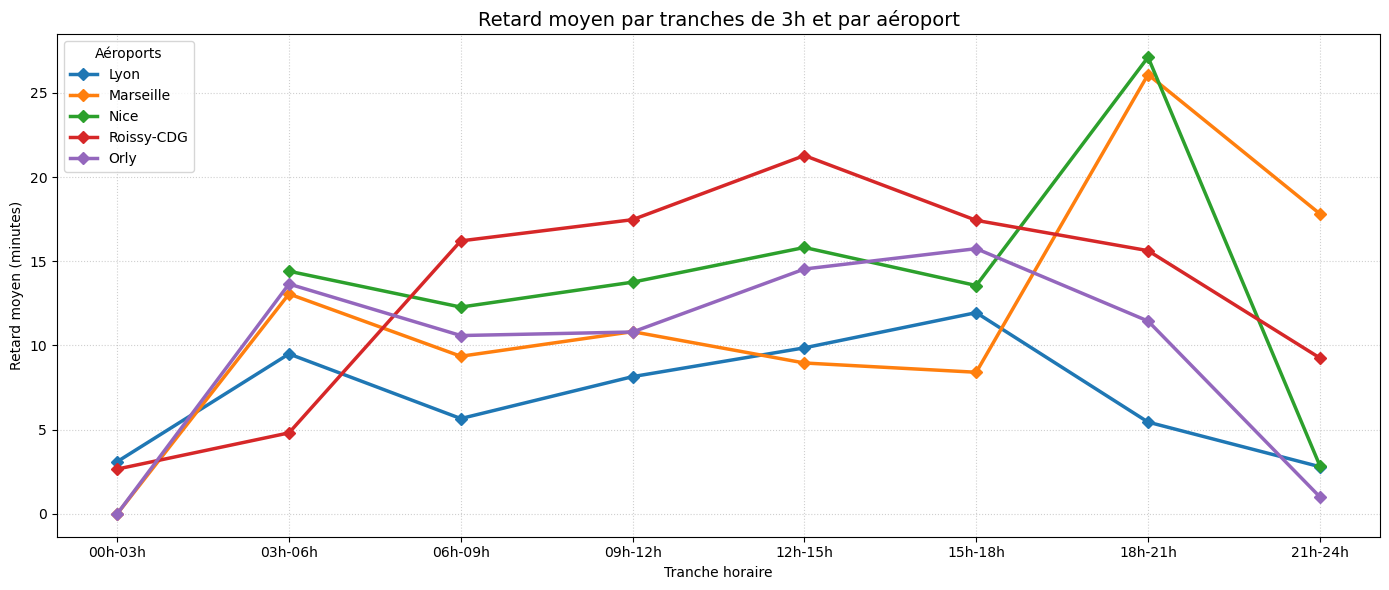

In [9]:
# =====================================================================
# VISUALISATION : Courbes de retard par aéroport
# =====================================================================

pivot_3h = df_5.pivot_table(
    values='delay_minutes',
    index='tranche_3h',
    columns='icao',
    aggfunc='mean'
).round(2)
pivot_3h.columns = pivot_3h.columns.map(AEROPORTS_CIBLES)

fig, ax = plt.subplots(figsize=(14, 6))
for aeroport in pivot_3h.columns:
    ax.plot(pivot_3h.index, pivot_3h[aeroport],
            marker='D', linewidth=2.5, markersize=6, label=aeroport)

ax.set_title("Retard moyen par tranches de 3h et par aéroport", fontsize=14)
ax.set_xlabel("Tranche horaire")
ax.set_ylabel("Retard moyen (minutes)")
ax.legend(title="Aéroports", loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [10]:
# =====================================================================
# PRODUCTIVITÉ PAR PISTE — indicateur de saturation opérationnelle
# =====================================================================

aeroports_data = {
    'LFPG': {'nom': 'Roissy-CDG', 'pistes': 4},
    'LFPO': {'nom': 'Orly',       'pistes': 3},
    'LFML': {'nom': 'Marseille',  'pistes': 2},
    'LFMN': {'nom': 'Nice',       'pistes': 2},
    'LFLL': {'nom': 'Lyon',       'pistes': 2},
}

df_5['just_date'] = df_5[DATE_COL].dt.date
vols_par_jour = df_5.groupby(['icao', 'just_date']).size().reset_index(name='nb_vols')
moy_quotidienne = vols_par_jour.groupby('icao')['nb_vols'].mean()

resultats_prod = []
for icao, moy in moy_quotidienne.items():
    nb_pistes = aeroports_data[icao]['pistes']
    resultats_prod.append({
        'Aéroport': aeroports_data[icao]['nom'],
        'Vols/Jour (Total)': round(moy, 1),
        'Nb Pistes': nb_pistes,
        'Vols/Jour/Piste': round(moy / nb_pistes, 2),
    })

df_prod = pd.DataFrame(resultats_prod).sort_values('Vols/Jour/Piste', ascending=False)
print("--- Productivité par piste (indicateur de saturation) ---")
print(df_prod.to_string(index=False))

--- Productivité par piste (indicateur de saturation) ---
  Aéroport  Vols/Jour (Total)  Nb Pistes  Vols/Jour/Piste
Roissy-CDG             2180.3          4           545.07
      Orly              410.9          3           136.97
      Lyon              154.5          2            77.24
      Nice              110.5          2            55.24
 Marseille               71.7          2            35.86


## 5. Nettoyage des données

Étapes :
1. Suppression des lignes sans `delay_minutes` (valeur cible)
2. Imputation par la médiane pour les variables météo
3. Destination manquante → `'UNKNOWN'` pour les arrivées par le bon icao
4. Suppression des outliers extrêmes (retards hors [-30min, +3h])
5. Suppression des colonnes à risque de leakage

In [11]:
# # =====================================================================
# # NETTOYAGE DES DONNÉES
# # =====================================================================

# print(f"Shape initial : {df_train.shape}")

# # --- 1. Suppression des lignes sans valeur cible ---
# # Sans delay_minutes on ne peut ni entraîner ni évaluer - pas d'imputation par la médiane sinon BRUIT !
# df_clean = df_train.dropna(subset=['delay_minutes']).copy()
# print(f"Après drop delay_minutes nul : {df_clean.shape[0]:,} lignes "
#       f"({df_clean.shape[0]/df_train.shape[0]*100:.1f}% conservés)")

# # --- 2. Imputation météo par la médiane ---
# # La médiane est robuste aux pics extrêmes (tempêtes, canicules...)
# METEO_COLS = [
#     'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
#     'wind_gusts_10m', 'pressure_msl', 'precipitation', 'cloud_cover'
# ]
# for col in METEO_COLS:
#     if col in df_clean.columns:
#         median_val = df_clean[col].median()
#         nb_imputed = df_clean[col].isna().sum()
#         df_clean[col] = df_clean[col].fillna(median_val)
#         if nb_imputed > 0:
#             print(f"  Imputé {col:<30s}: {nb_imputed} valeurs -> médiane {median_val:.2f}")

# # --- 3.quand l'API renseigne la colonne ICAO  elle met automatiquement la colonne destination_icao inconnue - il faut donc remplacer le contenu de cette colonne ---
# df_clean['dest_icao_clean'] = df_clean.apply(
#     lambda row: row['icao'] if row['type'] == "arrival" else row['destination_icao'], 
#     axis=1
# )

# # --- 4. Suppression des outliers extrêmes sur delay_minutes ---
# # On conserve les retards entre -30min et +3h 
# LOWER_BOUND, UPPER_BOUND = -30, 180
# before = len(df_clean)
# df_clean = df_clean[
#     (df_clean['delay_minutes'] >= LOWER_BOUND) &
#     (df_clean['delay_minutes'] <= UPPER_BOUND)
# ].copy()
# print(f"Après suppression outliers : {len(df_clean):,} lignes "
#       f"(retiré {before - len(df_clean):,} outliers)")

# # --- 5. Colonnes inutiles / leakage ---
# # revised_utc / runway_utc : informations connues APRÈS le vol -> leakage
# # quality_dep/arr : métadonnées source sans valeur prédictive
# COLS_TO_DROP_INIT = ['revised_utc', 'runway_utc', 'baggage_belt', 'quality_dep', 'quality_arr']
# df_clean = df_clean.drop(columns=COLS_TO_DROP_INIT, errors='ignore')

# print(f"\n✅ Shape final nettoyé : {df_clean.shape}")
# print("\nNaN restants (colonnes > 0%) :")
# na_rem = (df_clean.isna().sum() / len(df_clean) * 100)
# print(na_rem[na_rem > 0].sort_values(ascending=False))

In [12]:
# =====================================================================
# NETTOYAGE DES DONNÉES (CORRIGÉ)
# =====================================================================

# 1. Suppression des lignes sans valeur cible
df_clean = df_train.dropna(subset=['delay_minutes']).copy()

# 2. Imputation météo (médiane) - Inchangé
METEO_COLS = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_gusts_10m', 'pressure_msl', 'precipitation', 'cloud_cover']
for col in METEO_COLS:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 3. FIX DESTINATION : On écrase l'ancienne colonne pour ne pas se tromper plus tard
# On passe en minuscule pour le test
df_clean['type'] = df_clean['type'].str.lower()

# Si c'est une arrivée, la destination est l'aéroport actuel (icao)
mask_arrival = (df_clean['type'] == 'arrival')
df_clean.loc[mask_arrival, 'destination_icao'] = df_clean.loc[mask_arrival, 'destination_icao'].fillna(df_clean['icao'])

# Pour TOUT le reste (les quelques départs vides), on met 'UNKNOWN'
# C'est CRUCIAL pour que le Modèle Linéaire ne crée pas de colonne "None"
df_clean['destination_icao'] = df_clean['destination_icao'].fillna('UNKNOWN')

# 4. Suppression des outliers (Inchangé)
LOWER_BOUND, UPPER_BOUND = -30, 180
df_clean = df_clean[(df_clean['delay_minutes'] >= LOWER_BOUND) & (df_clean['delay_minutes'] <= UPPER_BOUND)].copy()

print(f"✅ Nettoyage terminé. NaN dans destination_icao : {df_clean['destination_icao'].isna().sum()}")

✅ Nettoyage terminé. NaN dans destination_icao : 0


## 6. Feature Engineering

**Variables créées :**
- `flight_key` : identifiant par rotation (ex: `AF_7313`)
- `airline_group` : regroupement des compagnies rares (<800 vols) → `OTHER`
- Features historiques : retard moyen par compagnie, par vol, par heure
- Encodage cyclique : `hour_sin/cos`, `dow_sin/cos`
- `time_period` : catégorie de moment de la journée
- `weather_index` : indice météo composite normalisé
- `is_delayed_15` : cible binaire (retard > 15 min)

In [13]:
# =====================================================================
# FEATURE ENGINEERING — PIPELINE COMPLET
# =====================================================================

df_fe = df_clean.copy()

# ===================================================================
# A. Features COMPAGNIE & VOL
# ===================================================================

# Parsing du numéro de vol : "AF 7313" -> designator="AF", number="7313"
df_fe['flight_number'] = df_fe['flight_number'].astype(str).str.strip()
split = df_fe['flight_number'].str.split(n=1, expand=True)
df_fe['airline_designator'] = split[0]
df_fe['flight_number_only'] = split[1].fillna('')

# Clé unique par rotation (ex: "AF_7313")
df_fe['flight_key'] = (
    df_fe['airline_designator'] + '_' + df_fe['flight_number_only']
).str.replace(r'\s+', '', regex=True)
df_fe['flight_key'] = df_fe['flight_key'].replace('', 'UNKNOWN')

# Regroupement des petites compagnies (< 800 vols) -> "OTHER"
# Evite l'overfitting sur des entités sous-représentées
freq_comp = df_fe['airline_designator'].value_counts()
compagnies_rares = freq_comp[freq_comp < 800].index
df_fe['airline_group'] = df_fe['airline_designator'].where(
    ~df_fe['airline_designator'].isin(compagnies_rares), 'OTHER'
)
print(f"Nb catégories airline_group : {df_fe['airline_group'].nunique()}")

# Cible binaire (retard significatif > 15 min selon normes DGAC)
df_fe['is_delayed_15'] = (df_fe['delay_minutes'] > 15).astype(int)

# Features historiques par compagnie
# NOTE : ces features sont calculées sur le dataset train entier.
#        En production, les calculer sur un lookup table figé.
#calcul des retards moyens de chaque compagnie
df_fe['avg_delay_airline']       = df_fe.groupby('airline_group')['delay_minutes'].transform('mean')
df_fe['pct_delayed_15_airline']  = df_fe.groupby('airline_group')['is_delayed_15'].transform('mean')
df_fe['airline_frequency']       = df_fe.groupby('airline_group')['airline_group'].transform('count')

# Features historiques par vol spécifique
df_fe['flight_frequency']        = df_fe.groupby('flight_key')['flight_key'].transform('count')
df_fe['avg_delay_flight_key']    = df_fe.groupby('flight_key')['delay_minutes'].transform('mean')

# Ratio vol/compagnie : mesure si un vol est plus fréquent que la moyenne de sa compagnie
df_fe['flight_to_airline_ratio'] = df_fe['flight_frequency'] / df_fe['airline_frequency']

# ===================================================================
# B. Features TEMPORELLES
# ===================================================================

DATE_COL = 'scheduled_utc' if 'scheduled_utc' in df_fe.columns else 'date'
df_fe[DATE_COL] = pd.to_datetime(df_fe[DATE_COL], utc=True, errors='coerce')

df_fe['scheduled_hour']      = df_fe[DATE_COL].dt.hour
df_fe['scheduled_minute']    = df_fe[DATE_COL].dt.minute
df_fe['scheduled_dayofweek'] = df_fe[DATE_COL].dt.dayofweek  # 0 = Lundi
df_fe['scheduled_month']     = df_fe[DATE_COL].dt.month

# Encodage cyclique heure et jour de semaine
# -> indispensable pour les modèles linéaires : 23h doit être "proche" de 00h
df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['scheduled_hour'] / 24)
df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['scheduled_hour'] / 24)
df_fe['dow_sin']  = np.sin(2 * np.pi * df_fe['scheduled_dayofweek'] / 7)
df_fe['dow_cos']  = np.cos(2 * np.pi * df_fe['scheduled_dayofweek'] / 7)

# Période de la journée (feature catégorielle utile pour les arbres de décision)
def get_time_period(hour):
    if pd.isna(hour): return 'unknown'
    if  5 <= hour <  9: return 'pic_matin'
    if  9 <= hour < 12: return 'matin'
    if 12 <= hour < 17: return 'apres_midi'
    if 17 <= hour < 21: return 'pic_soir'
    return 'nuit'

df_fe['time_period'] = df_fe['scheduled_hour'].apply(get_time_period)

# Statistiques historiques par créneau temporel
df_fe['avg_delay_by_hour']       = df_fe.groupby('scheduled_hour')['delay_minutes'].transform('mean')
df_fe['avg_delay_by_dayofweek']  = df_fe.groupby('scheduled_dayofweek')['delay_minutes'].transform('mean')
df_fe['avg_delay_by_timeperiod'] = df_fe.groupby('time_period')['delay_minutes'].transform('mean')
df_fe['pct_delayed_by_hour']     = df_fe.groupby('scheduled_hour')['is_delayed_15'].transform('mean')

# ===================================================================
# C. Feature MÉTÉO COMPOSITE
# ===================================================================

# Indice météo normalisé : moyenne de 3 variables clés normalisées entre 0 et 1
# Plus l'indice est élevé, plus les conditions météo sont dégradées
WEATHER_COLS = ['wind_speed_10m', 'precipitation', 'cloud_cover']
available_w = [c for c in WEATHER_COLS if c in df_fe.columns]
if available_w:
    for col in available_w:
        max_val = df_fe[col].max() if df_fe[col].max() > 0 else 1
        df_fe[f'norm_{col}'] = df_fe[col] / max_val
    df_fe['weather_index'] = df_fe[[f'norm_{c}' for c in available_w]].mean(axis=1)
else:
    df_fe['weather_index'] = 0.0

# ===================================================================
# D. Suppression des colonnes redondantes après feature engineering
# ===================================================================

COLS_TO_DROP_FE = [
    'flight_number',       # remplacé par flight_key
    'flight_number_only',  # intermédiaire de calcul
    'airline_designator',  # remplacé par airline_group
    'status',              # information postérieure au vol -> leakage
    DATE_COL,              # entièrement décomposée en features
    'day_of_week',         # doublon de scheduled_dayofweek
]
df_fe = df_fe.drop(columns=COLS_TO_DROP_FE, errors='ignore')

print(f"\n✅ Feature Engineering terminé | Shape : {df_fe.shape}")

Nb catégories airline_group : 42

✅ Feature Engineering terminé | Shape : (246099, 71)


## 7. Préparation finale pour la modélisation

In [18]:
# =====================================================================
# SÉLECTION DES FEATURES FINALES
# =====================================================================

# Numériques
NUM_FEATURES = [
    # Météo brute
    'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
    'wind_gusts_10m', 'pressure_msl', 'precipitation', 'cloud_cover',
    'weather_index',
    # Temporel cyclique (pour les modèles linéaires)
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'scheduled_hour', 'scheduled_minute', 'scheduled_dayofweek', 'scheduled_month',
    # Métier compagnie / vol
    'avg_delay_airline', 'pct_delayed_15_airline',
    'flight_frequency', 'avg_delay_flight_key',
    'airline_frequency', 'flight_to_airline_ratio',
    # Stats historiques temporelles
    'avg_delay_by_hour', 'avg_delay_by_dayofweek',
    'avg_delay_by_timeperiod', 'pct_delayed_by_hour',
    # Avion
    'num_seats',
]

# # Catégorielles
# CAT_FEATURES = [
#     'airline_group',
#     'destination_icao',
#     'aircraft_family',
#     'time_period',
# ]
# Catégorielles
CAT_FEATURES = [
    'airline_group',
    'destination_icao', # Maintenant elle est propre (0 NaN)
    'aircraft_family',
    'time_period',
]

# Filtrage sur les 5 aéroports cibles
df_model = df_fe[df_fe['icao'].isin(AEROPORTS_CIBLES.keys())].copy()

# Sécurité : on ne garde que les features réellement présentes dans le df
num_available = [f for f in NUM_FEATURES if f in df_model.columns]
cat_available = [f for f in CAT_FEATURES if f in df_model.columns]

X = df_model[num_available + cat_available]
y = df_model['delay_minutes']   # TARGET : minutes de retard (régression)

print(f"Features numériques    : {len(num_available)}")
print(f"Features catégorielles : {len(cat_available)}")
print(f"Shape X : {X.shape}")
print(f"\nDistribution y (delay_minutes) :")
print(y.describe().round(2))

Features numériques    : 27
Features catégorielles : 4
Shape X : (246099, 31)

Distribution y (delay_minutes) :
count    246099.00
mean         15.56
std          27.42
min         -30.00
25%          -2.00
50%          12.00
75%          26.00
max         180.00
Name: delay_minutes, dtype: float64


In [19]:
# =====================================================================
# SPLIT TRAIN / TEST et PRÉPROCESSEUR
# =====================================================================

# Split aléatoire avec random_state pour la reproductibilité
# NOTE : pour un projet en production avec features historiques (avg_delay...),
#        utiliser un split temporel strict via un cutoff de date
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Train : {X_train.shape[0]:,} lignes")
print(f"Test  : {X_test.shape[0]:,} lignes ({X_test.shape[0]/len(X)*100:.0f}%)")

# Préprocesseur commun à tous les modèles
# StandardScaler : centre et réduit les variables numériques
# OneHotEncoder  : handle_unknown='ignore' -> gère les nouvelles compagnies en prod
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_available),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_available),
], remainder='drop')

print("\n✅ Préprocesseur configuré — prêt pour la modélisation")

Train : 196,879 lignes
Test  : 49,220 lignes (20%)

✅ Préprocesseur configuré — prêt pour la modélisation


## 8. Modélisation & Logging MLflow

| # | Modèle | Intérêt |
|---|--------|---------|
| 1 | **LinearRegression** | Baseline pure, interprétable |
| 2 | **Ridge (L2)** | Contrôle la multicolinéarité |
| 3 | **Lasso (L1)** | Sélection de features implicite |
| 4 | **RandomForest** | Non-linéaire, robuste aux outliers |

In [20]:
# =====================================================================
# FONCTION DE LOGGING MLFLOW
# Centralise l'évaluation et le logging pour éviter les duplications
# =====================================================================

def log_model_to_mlflow(pipeline, model_name: str, X_test, y_test,
                         extra_params: dict = None) -> dict:
    """Evalue un pipeline sklearn et log les résultats dans MLflow.

    Args:
        pipeline     : Pipeline sklearn déjà entraîné
        model_name   : Nom du run MLflow
        X_test       : Features de test
        y_test       : Cible de test
        extra_params : Hyperparamètres à logger (optionnel)

    Returns:
        dict avec mae, rmse, r2
    """
    with mlflow.start_run(run_name=model_name):
        preds = pipeline.predict(X_test)

        mae  = mean_absolute_error(y_test, preds)
        rmse = root_mean_squared_error(y_test, preds)
        r2   = r2_score(y_test, preds)

        # Métriques
        mlflow.log_metric("mae",  mae)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("r2",   r2)

        # Hyperparamètres
        if extra_params:
            mlflow.log_params(extra_params)

        # Modèle sérialisé avec signature (utile pour valider le schéma en prod)
        signature = infer_signature(X_test, preds)
        mlflow.sklearn.log_model(pipeline, "model", signature=signature)

        # Tags communs à tous les runs
        mlflow.set_tag("projet",    "ppml-retards-avion")
        mlflow.set_tag("aeroports", ",".join(AEROPORTS_CIBLES.keys()))

        print(f"  ✅ {model_name:35s} | MAE: {mae:6.2f} | RMSE: {rmse:6.2f} | R²: {r2:.4f}")

    return {'model': model_name, 'mae': mae, 'rmse': rmse, 'r2': r2}

In [21]:
# =====================================================================
# ENTRAÎNEMENT DES 4 MODÈLES BASELINE EN BOUCLE
# =====================================================================

mlflow.set_experiment(EXPERIMENT_NAME)

# Configuration des pipelines
# clone(preprocessor) -> évite les effets de bord entre fits successifs
models_config = [
    {
        'name': '1_LinearRegression',
        'pipeline': Pipeline([('pre', clone(preprocessor)), ('reg', LinearRegression())]),
        'params': {}
    },
    {
        'name': '2_Ridge',
        'pipeline': Pipeline([('pre', clone(preprocessor)), ('reg', Ridge(alpha=1.0))]),
        'params': {'alpha': 1.0}
    },
    {
        'name': '3_Lasso',
        # alpha=0.01 pour éviter de pénaliser trop fort et de tout mettre à zéro
        'pipeline': Pipeline([('pre', clone(preprocessor)), ('reg', Lasso(alpha=0.01, max_iter=2000))]),
        'params': {'alpha': 0.01}
    },
    {
        'name': '4_RandomForest',
        'pipeline': Pipeline([
            ('pre', clone(preprocessor)),
            ('reg', RandomForestRegressor(
                n_estimators=100,
                max_depth=20,
                min_samples_split=5,
                n_jobs=-1,          # utilise tous les coeurs disponibles
                random_state=42
            ))
        ]),
        'params': {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5}
    },
]

# Entraînement et logging en boucle
results = []
print(f"{'Modèle':35s} | {'MAE':>6} | {'RMSE':>6} | {'R²':>8}")
print("-" * 65)

for cfg in models_config:
    cfg['pipeline'].fit(X_train, y_train)
    res = log_model_to_mlflow(
        pipeline=cfg['pipeline'],
        model_name=cfg['name'],
        X_test=X_test,
        y_test=y_test,
        extra_params=cfg['params']
    )
    results.append(res)

print(f"\n🎉 Tous les modèles loggés : {MLFLOW_REMOTE_URI}")

Modèle                              |    MAE |   RMSE |       R²
-----------------------------------------------------------------


2026/04/13 17:14:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 17:14:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✅ 1_LinearRegression                  | MAE:  14.70 | RMSE:  22.34 | R²: 0.3314
🏃 View run 1_LinearRegression at: https://stoneray-ppml-mlflow.hf.space/#/experiments/1/runs/6ec327f490b548a4a39400907139dd16
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/1


2026/04/13 17:15:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 17:15:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✅ 2_Ridge                             | MAE:  14.70 | RMSE:  22.34 | R²: 0.3315
🏃 View run 2_Ridge at: https://stoneray-ppml-mlflow.hf.space/#/experiments/1/runs/a6473e6f36c344a082ab6e7b1275e334
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/1


2026/04/13 17:16:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 17:16:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✅ 3_Lasso                             | MAE:  14.69 | RMSE:  22.32 | R²: 0.3326
🏃 View run 3_Lasso at: https://stoneray-ppml-mlflow.hf.space/#/experiments/1/runs/c216c220496549ad9470ac39eafe0ded
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/1


2026/04/13 17:22:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 17:22:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✅ 4_RandomForest                      | MAE:   9.62 | RMSE:  15.32 | R²: 0.6856
🏃 View run 4_RandomForest at: https://stoneray-ppml-mlflow.hf.space/#/experiments/1/runs/63e985091ace4b11a5ee81cc87f36758
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/1

🎉 Tous les modèles loggés : https://stoneray-ppml-mlflow.hf.space/


### 8.1 Comparaison des performances

--- Classement (MAE croissant — meilleur en haut) ---
                        mae     rmse      r2
model                                       
4_RandomForest       9.6195  15.3189  0.6856
3_Lasso             14.6860  22.3195  0.3326
2_Ridge             14.6967  22.3377  0.3315
1_LinearRegression  14.6984  22.3404  0.3314


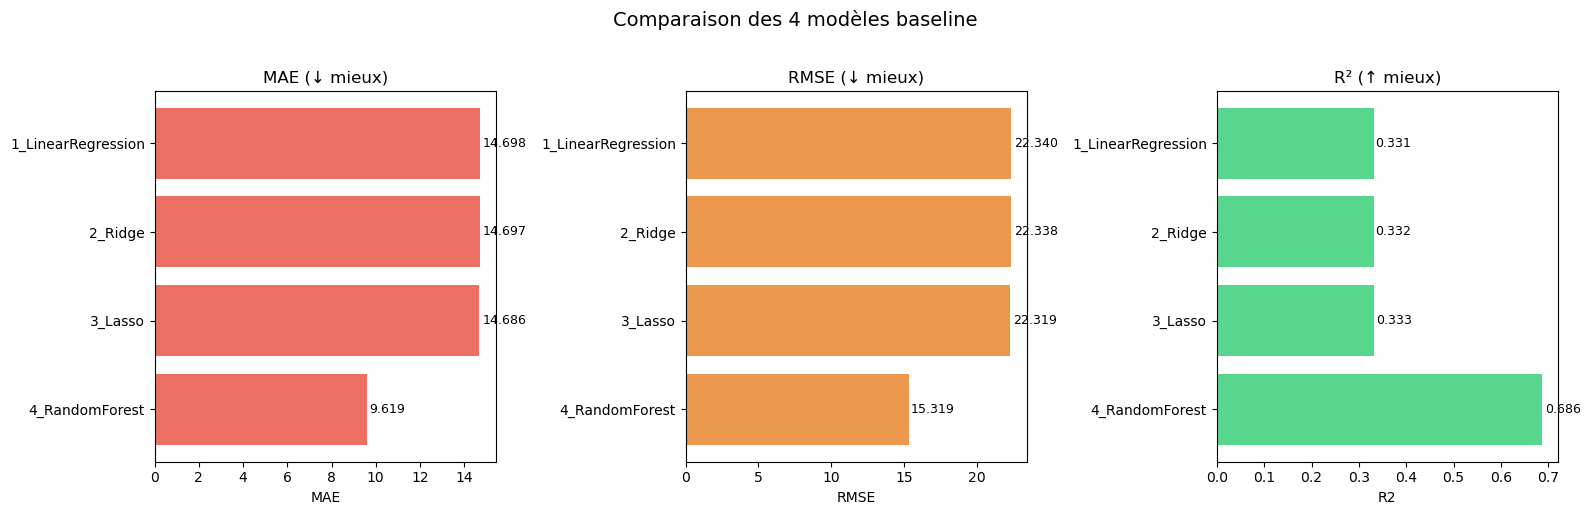

In [29]:
# =====================================================================
# VISUALISATION COMPARATIVE
# =====================================================================

df_results = pd.DataFrame(results).set_index('model').sort_values('mae')

print("--- Classement (MAE croissant — meilleur en haut) ---")
print(df_results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, title, color) in zip(axes, [
    ('mae',  'MAE (↓ mieux)',  '#e74c3c'),
    ('rmse', 'RMSE (↓ mieux)', '#e67e22'),
    ('r2',   'R² (↑ mieux)',   '#2ecc71'),
]):
    vals = df_results[metric]
    bars = ax.barh(df_results.index, vals, color=color, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(metric.upper())
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() * 1.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle("Comparaison des 4 modèles baseline", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Optimisation du meilleur modèle (RandomizedSearchCV)

In [23]:
# =====================================================================
# HYPERPARAMETER TUNING — RANDOM FOREST
# RandomizedSearch pour explorer l'espace de façon efficace
# n_iter=10 : ajuster selon le temps disponible (~2-5 min par itération)
# =====================================================================

param_distributions = {
    'reg__n_estimators':      [100, 150, 200],
    'reg__max_depth':         [15, 20, 25, None],
    'reg__min_samples_split': [2, 5, 10],
    'reg__min_samples_leaf':  [1, 2, 4],
    'reg__max_features':      ['sqrt', 'log2', 0.5],
}

rf_tuning_pipeline = Pipeline([
    ('pre', clone(preprocessor)),
    ('reg', RandomForestRegressor(n_jobs=-1, random_state=42))
])

random_search = RandomizedSearchCV(
    rf_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=10,          # Augmenter pour un tuning plus exhaustif
    cv=3,               # 3-fold cross-validation
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

print("Lancement du RandomizedSearchCV...")
random_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres :")
for k, v in random_search.best_params_.items():
    print(f"  {k:<30s}: {v}")

# Log du modèle optimisé dans MLflow
print("\nLogging dans MLflow...")
res_tuned = log_model_to_mlflow(
    pipeline=random_search.best_estimator_,
    model_name="5_RandomForest_Tuned",
    X_test=X_test,
    y_test=y_test,
    extra_params=random_search.best_params_
)

print(f"\n🏆 Modèle optimisé | MAE: {res_tuned['mae']:.2f} | R²: {res_tuned['r2']:.4f}")

Lancement du RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Meilleurs paramètres :
  reg__n_estimators             : 100
  reg__min_samples_split        : 5
  reg__min_samples_leaf         : 1
  reg__max_features             : 0.5
  reg__max_depth                : 25

Logging dans MLflow...


2026/04/13 17:58:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 17:58:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✅ 5_RandomForest_Tuned                | MAE:   8.34 | RMSE:  14.14 | R²: 0.7322
🏃 View run 5_RandomForest_Tuned at: https://stoneray-ppml-mlflow.hf.space/#/experiments/1/runs/8f37b3b42d50443e95935b36261d79ea
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/1

🏆 Modèle optimisé | MAE: 8.34 | R²: 0.7322


## 10. Analyse des importances de variables

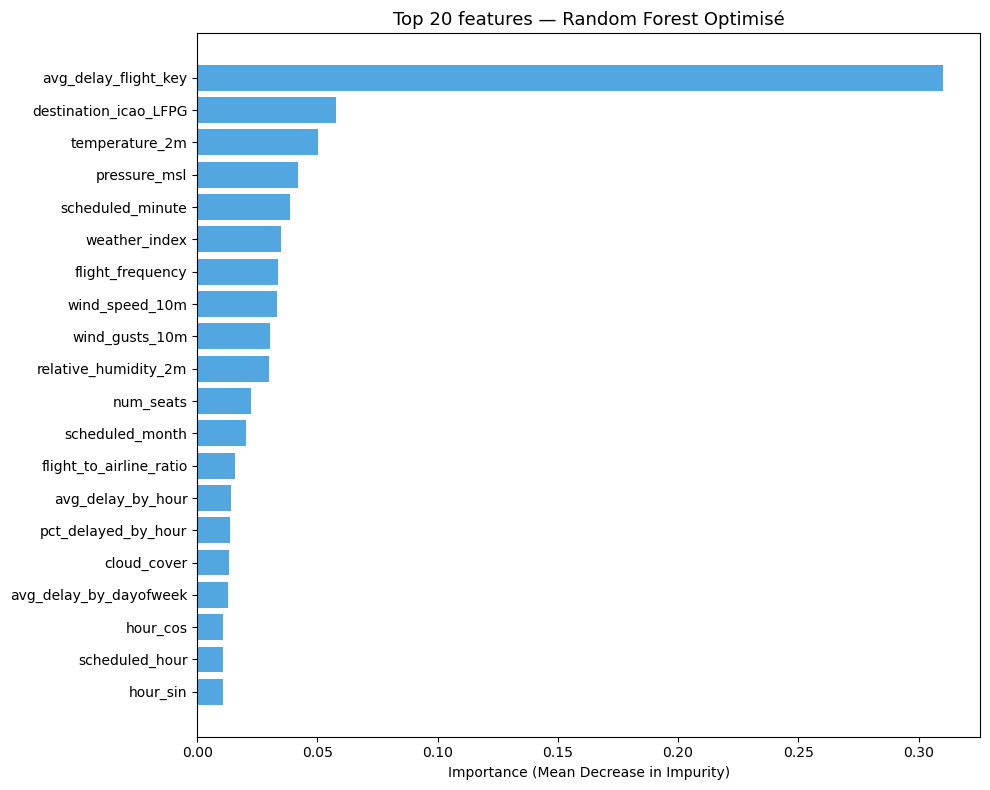


Top 10 features :
              feature  importance
 avg_delay_flight_key    0.310061
destination_icao_LFPG    0.057560
       temperature_2m    0.050053
         pressure_msl    0.042093
     scheduled_minute    0.038584
        weather_index    0.034796
     flight_frequency    0.033428
       wind_speed_10m    0.033239
       wind_gusts_10m    0.030366
 relative_humidity_2m    0.029976


In [26]:
# =====================================================================
# FEATURE IMPORTANCE DU RANDOM FOREST OPTIMISÉ
# Méthode MDI (Mean Decrease in Impurity)
# =====================================================================

best_model = random_search.best_estimator_

# Récupération des noms de features post-OHE via le ColumnTransformer
ohe_feature_names = (
    best_model.named_steps['pre']
    .named_transformers_['cat']
    .get_feature_names_out(cat_available)
    .tolist()
)
all_feature_names = num_available + ohe_feature_names

importances = best_model.named_steps['reg'].feature_importances_

df_importance = (
    pd.DataFrame({'feature': all_feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_importance['feature'][::-1], df_importance['importance'][::-1],
        color='#3498db', alpha=0.85)
ax.set_title("Top 20 features — Random Forest Optimisé", fontsize=13)
ax.set_xlabel("Importance (Mean Decrease in Impurity)")
plt.tight_layout()
plt.show()

print("\nTop 10 features :")
print(df_importance.head(10).to_string(index=False))

## 11. Récapitulatif final

In [28]:
# =====================================================================
# BILAN COMPLET DU PROJET
# =====================================================================

all_results = results + [res_tuned]

print("=" * 65)
print("  BILAN — PROJET PPML RETARDS AÉRIENS")
print("=" * 65)
print(f"  Dataset initial   : {df_train.shape[0]:,} vols | {df_train.shape[1]} colonnes")
print(f"  Après nettoyage   : {df_clean.shape[0]:,} lignes")
print(f"  Après FE          : {df_fe.shape[1]} colonnes")
print(f"  Features modèle   : {len(num_available) + len(cat_available)}")
print(f"  Train / Test      : {X_train.shape[0]:,} / {X_test.shape[0]:,} lignes")
print()
print("  Modèles loggés dans MLflow :")
print(f"  {'Modèle':38s} {'MAE':>6}  {'RMSE':>6}  {'R²':>8}")
print(f"  {'-'*62}")
for r in sorted(all_results, key=lambda x: x['mae']):
    print(f"  {r['model']:38s} {r['mae']:6.2f}  {r['rmse']:6.2f}  {r['r2']:8.4f}")
print()
print(f"  Interface MLflow : {MLFLOW_REMOTE_URI}")
print("=" * 65)

  BILAN — PROJET PPML RETARDS AÉRIENS
  Dataset initial   : 264,759 vols | 48 colonnes
  Après nettoyage   : 246,099 lignes
  Après FE          : 71 colonnes
  Features modèle   : 31
  Train / Test      : 196,879 / 49,220 lignes

  Modèles loggés dans MLflow :
  Modèle                                    MAE    RMSE        R²
  --------------------------------------------------------------
  5_RandomForest_Tuned                     8.34   14.14    0.7322
  4_RandomForest                           9.62   15.32    0.6856
  3_Lasso                                 14.69   22.32    0.3326
  2_Ridge                                 14.70   22.34    0.3315
  1_LinearRegression                      14.70   22.34    0.3314

  Interface MLflow : https://stoneray-ppml-mlflow.hf.space/
